<div style="border-radius:10px; padding: 15px; background-color: #CDE8E5; font-size:130%; text-align:left; color: #fffff">

<h2 align="left"><font color=#4D869C>Problem:</font></h2>

The problem at hand involves predicting whether individuals have diabetes based on a dataset containing various medical and demographic features. Each record in the dataset represents a person, and the target variable indicates the presence or absence of diabetes. The task is to explore and evaluate several machine learning and deep learning algorithms to determine which model performs best in predicting diabetes. The evaluation criterion for comparing the algorithms is the F1 score, a metric that balances precision and recall, making it well-suited for potentially imbalanced medical classification problems. The ultimate goal is to identify the algorithm that achieves the highest F1 score, indicating its effectiveness in accurately classifying individuals as diabetic or non-diabetic.

    
Sajjad Hadadi



<div style="border-radius:10px; padding: 15px; background-color: #CDE8E5; font-size:130%; text-align:left">

<h2 align="left"><font color=#4D869C>Objectives:</font></h2>


- **Data Cleaning & Transformation**: Clean the dataset by handling missing values, duplicates, and outliers, preparing it for effective modeling. This involves:
  - Identifying and imputing or removing missing values.
  - Detecting and removing duplicate entries.
  - Identifying and treating outliers to avoid skewed results.
  - Converting data types where necessary to ensure consistency and accuracy.

- **Feature Engineering**: Explore and create new features from the existing dataset that might improve the predictive power of the models. This could involve:
  - Extracting meaningful information from the available features.
  - Creating new features through aggregation, polynomial transformations, or domain-specific knowledge.
  - Encoding categorical variables into numerical formats (e.g., one-hot encoding, label encoding).
  - Combining features in insightful ways to capture complex patterns.

- **Data Preprocessing**: Standardize, encode, or normalize features as necessary to prepare the data for model training. This step aims to ensure that the algorithms can effectively learn from the data and make accurate predictions. Key tasks include:
  - Standardizing features to have a mean of zero and a standard deviation of one.
  - Normalizing features to a specific range (e.g., 0 to 1).
  - Encoding categorical variables appropriately.
  - Splitting the dataset into training and testing sets to evaluate model performance.

- **Model Selection**: Test various machine learning and deep learning algorithms to identify the most effective model for the task. This process involves:
  - Experimenting with different machine learning models such as linear regression, decision trees, random forests, support vector machines, and gradient boosting machines.
  - Exploring deep learning models such as neural networks and convolutional neural networks if applicable.
  - Evaluating models based on F1 score to determine the best performing model.



<a id="contents_tabel"></a>    
<div style="border-radius:10px; padding: 15px; background-color: #CDE8E5; font-size:130%; text-align:left">

<h2 align="left"><font color=#4D869C>Table of Contents:</font></h2>
    
* [Step 1 | Setup and Initial Data Analysis](#initial_analysis)  
* [Step 2 | Data Cleaning & Transformation](#data_cleaning)
* [Step 3 | Exploratory Data Analysis](#eda)
* [Step 4 | Data Preprocessing](#preprocessing)
* [Step 5 | Model Selection](#modeling)
    - [Step 5.1 | Logistic Regression](#logistic)
    - [Step 5.2 | Decision Trees](#decisiontrees)
    - [Step 5.3 | Random Forest](#randomforest)
    - [Step 5.4 | Support Vector Machines](#svm)
    - [Step 5.5 | XGboost](#xgboost)
    - [Step 5.6 | Fully Connected Neural Networks](#nn)
* [Step 6 | Conclusions & Comparison of different models](#conclusions)

<a id="#initial_analysis"></a>
# <p style="background-color: #4D869C; font-family:calibri; color:white; font-size:135%; font-family:Verdana; text-align:center; border-radius:15px 50px; padding: 15px;">Step 1 | Setup and Initialization</p>
⬆️ [Tabel of Contents](#contents_tabel)

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, Normalizer, OneHotEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score, classification_report
from sklearn.utils import resample

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [3]:
data = pd.read_csv('/kaggle/input/playground-series-s5e12/train.csv')
data.head()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [4]:
data.shape

(700000, 26)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_rate                

In [6]:
data.nunique()

id                                    700000
age                                       71
alcohol_consumption_per_week               9
physical_activity_minutes_per_week       565
diet_score                                99
sleep_hours_per_day                       69
screen_time_hours_per_day                151
bmi                                      231
waist_to_hip_ratio                        36
systolic_bp                               71
diastolic_bp                              54
heart_rate                                60
cholesterol_total                        154
hdl_cholesterol                           69
ldl_cholesterol                          151
triglycerides                            228
gender                                     3
ethnicity                                  5
education_level                            4
income_level                               5
smoking_status                             3
employment_status                          4
family_his

In [7]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,700000.0,349999.500000,202072.738554,0.00,174999.75,349999.50,524999.25,699999.00
age,700000.0,50.359734,11.655520,19.00,42.00,50.00,58.00,89.00
alcohol_consumption_per_week,700000.0,2.072411,1.048189,1.00,1.00,2.00,3.00,9.00
physical_activity_minutes_per_week,700000.0,80.230803,51.195071,1.00,49.00,71.00,96.00,747.00
diet_score,700000.0,5.963695,1.463336,0.10,5.00,6.00,7.00,9.90
sleep_hours_per_day,700000.0,7.002200,0.901907,3.10,6.40,7.00,7.60,9.90
screen_time_hours_per_day,700000.0,6.012733,2.022707,0.60,4.60,6.00,7.40,16.50
bmi,700000.0,25.874684,2.860705,15.10,23.90,25.90,27.80,38.40
waist_to_hip_ratio,700000.0,0.858766,0.037980,0.68,0.83,0.86,0.88,1.05
systolic_bp,700000.0,116.294193,11.010390,91.00,108.00,116.00,124.00,163.00


In [8]:
data.describe(include="object").T

,count,unique,top,freq
gender,700000,3,Female,363237
ethnicity,700000,5,White,386153
education_level,700000,4,Highschool,344145
income_level,700000,5,Middle,290557
smoking_status,700000,3,Never,494448
employment_status,700000,4,Employed,516170


In [9]:
data.columns

Index(['id', 'age', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi',
       'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol',
       'triglycerides', 'gender', 'ethnicity', 'education_level',
       'income_level', 'smoking_status', 'employment_status',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'diagnosed_diabetes'],
      dtype='object')

<a id="data_cleaning"></a>
# <p style="background-color: #4D869C; font-family:calibri; color:white; font-size:135%; font-family:Verdana; text-align:center; border-radius:15px 50px;  padding: 15px;">Step 2 | Data Cleaning & Transformation</p>
⬆️ [Tabel of Contents](#contents_tabel)

# <b><span style='color:#CDE8E5'>Step 2.1 |</span><span style='color:#4D869C'> Handling Missing Values</span></b>

In [1]:
# percentage of missing values
(data.isnull().sum()[data.isnull().sum() > 0] / data.shape[0]) * 100

NameError: name 'data' is not defined

In [ ]:
from sklearn.impute import KNNImputer, SimpleImputer

knnim = KNNImputer(n_neighbors=3)
si = SimpleImputer(fill_value=data["column1"].mean(), missing_values=-1)

# <b><span style='color:#CDE8E5'>Step 2.2 |</span><span style='color:#4D869C'> Handling Duplicates</span></b>

In [11]:
# Showing the number of duplicate rows
print(f"\nThe dataset contains {data.duplicated().sum()} duplicate rows.")


The dataset contains 0 duplicate rows.


In [12]:
# finding and show duplicated rows
# data[data.duplicated(keep=False)].head(5)

# <b><span style='color:#CDE8E5'>Step 2.3 |</span><span style='color:#4D869C'> Drop "Id" column</span></b>

In [13]:
data.drop(['id'], axis=1, inplace=True)

# <b><span style='color:#CDE8E5'>Step 2.4 |</span><span style='color:#4D869C'> Convert to 32bit</span></b>

In [14]:
data[data.select_dtypes("int64").columns] = data.select_dtypes("int64").astype("int32")
data[data.select_dtypes("float64").columns] = data.select_dtypes("float64").astype("float32")

# <p style="background-color: #4D869C; font-family:calibri; color:white; font-size:135%; font-family:Verdana; text-align:center; border-radius:15px 50px;  padding: 10px;">Step 3 | Exploratory Data Analysis:</p>

In [15]:
def plot_histograms(dataframe):
    num_columns = len(dataframe.columns)
    num_rows = (num_columns // 5) + int(num_columns % 5 != 0)

    fig, axes = plt.subplots(num_rows, 5, figsize=(20, 4 * num_rows))
    axes = axes.flatten()

    for i, column in enumerate(dataframe.columns):
        sns.histplot(dataframe[column], ax=axes[i])
        axes[i].set_title(f'Distribution of {column}')

    for i in range(num_columns, num_rows * 5):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

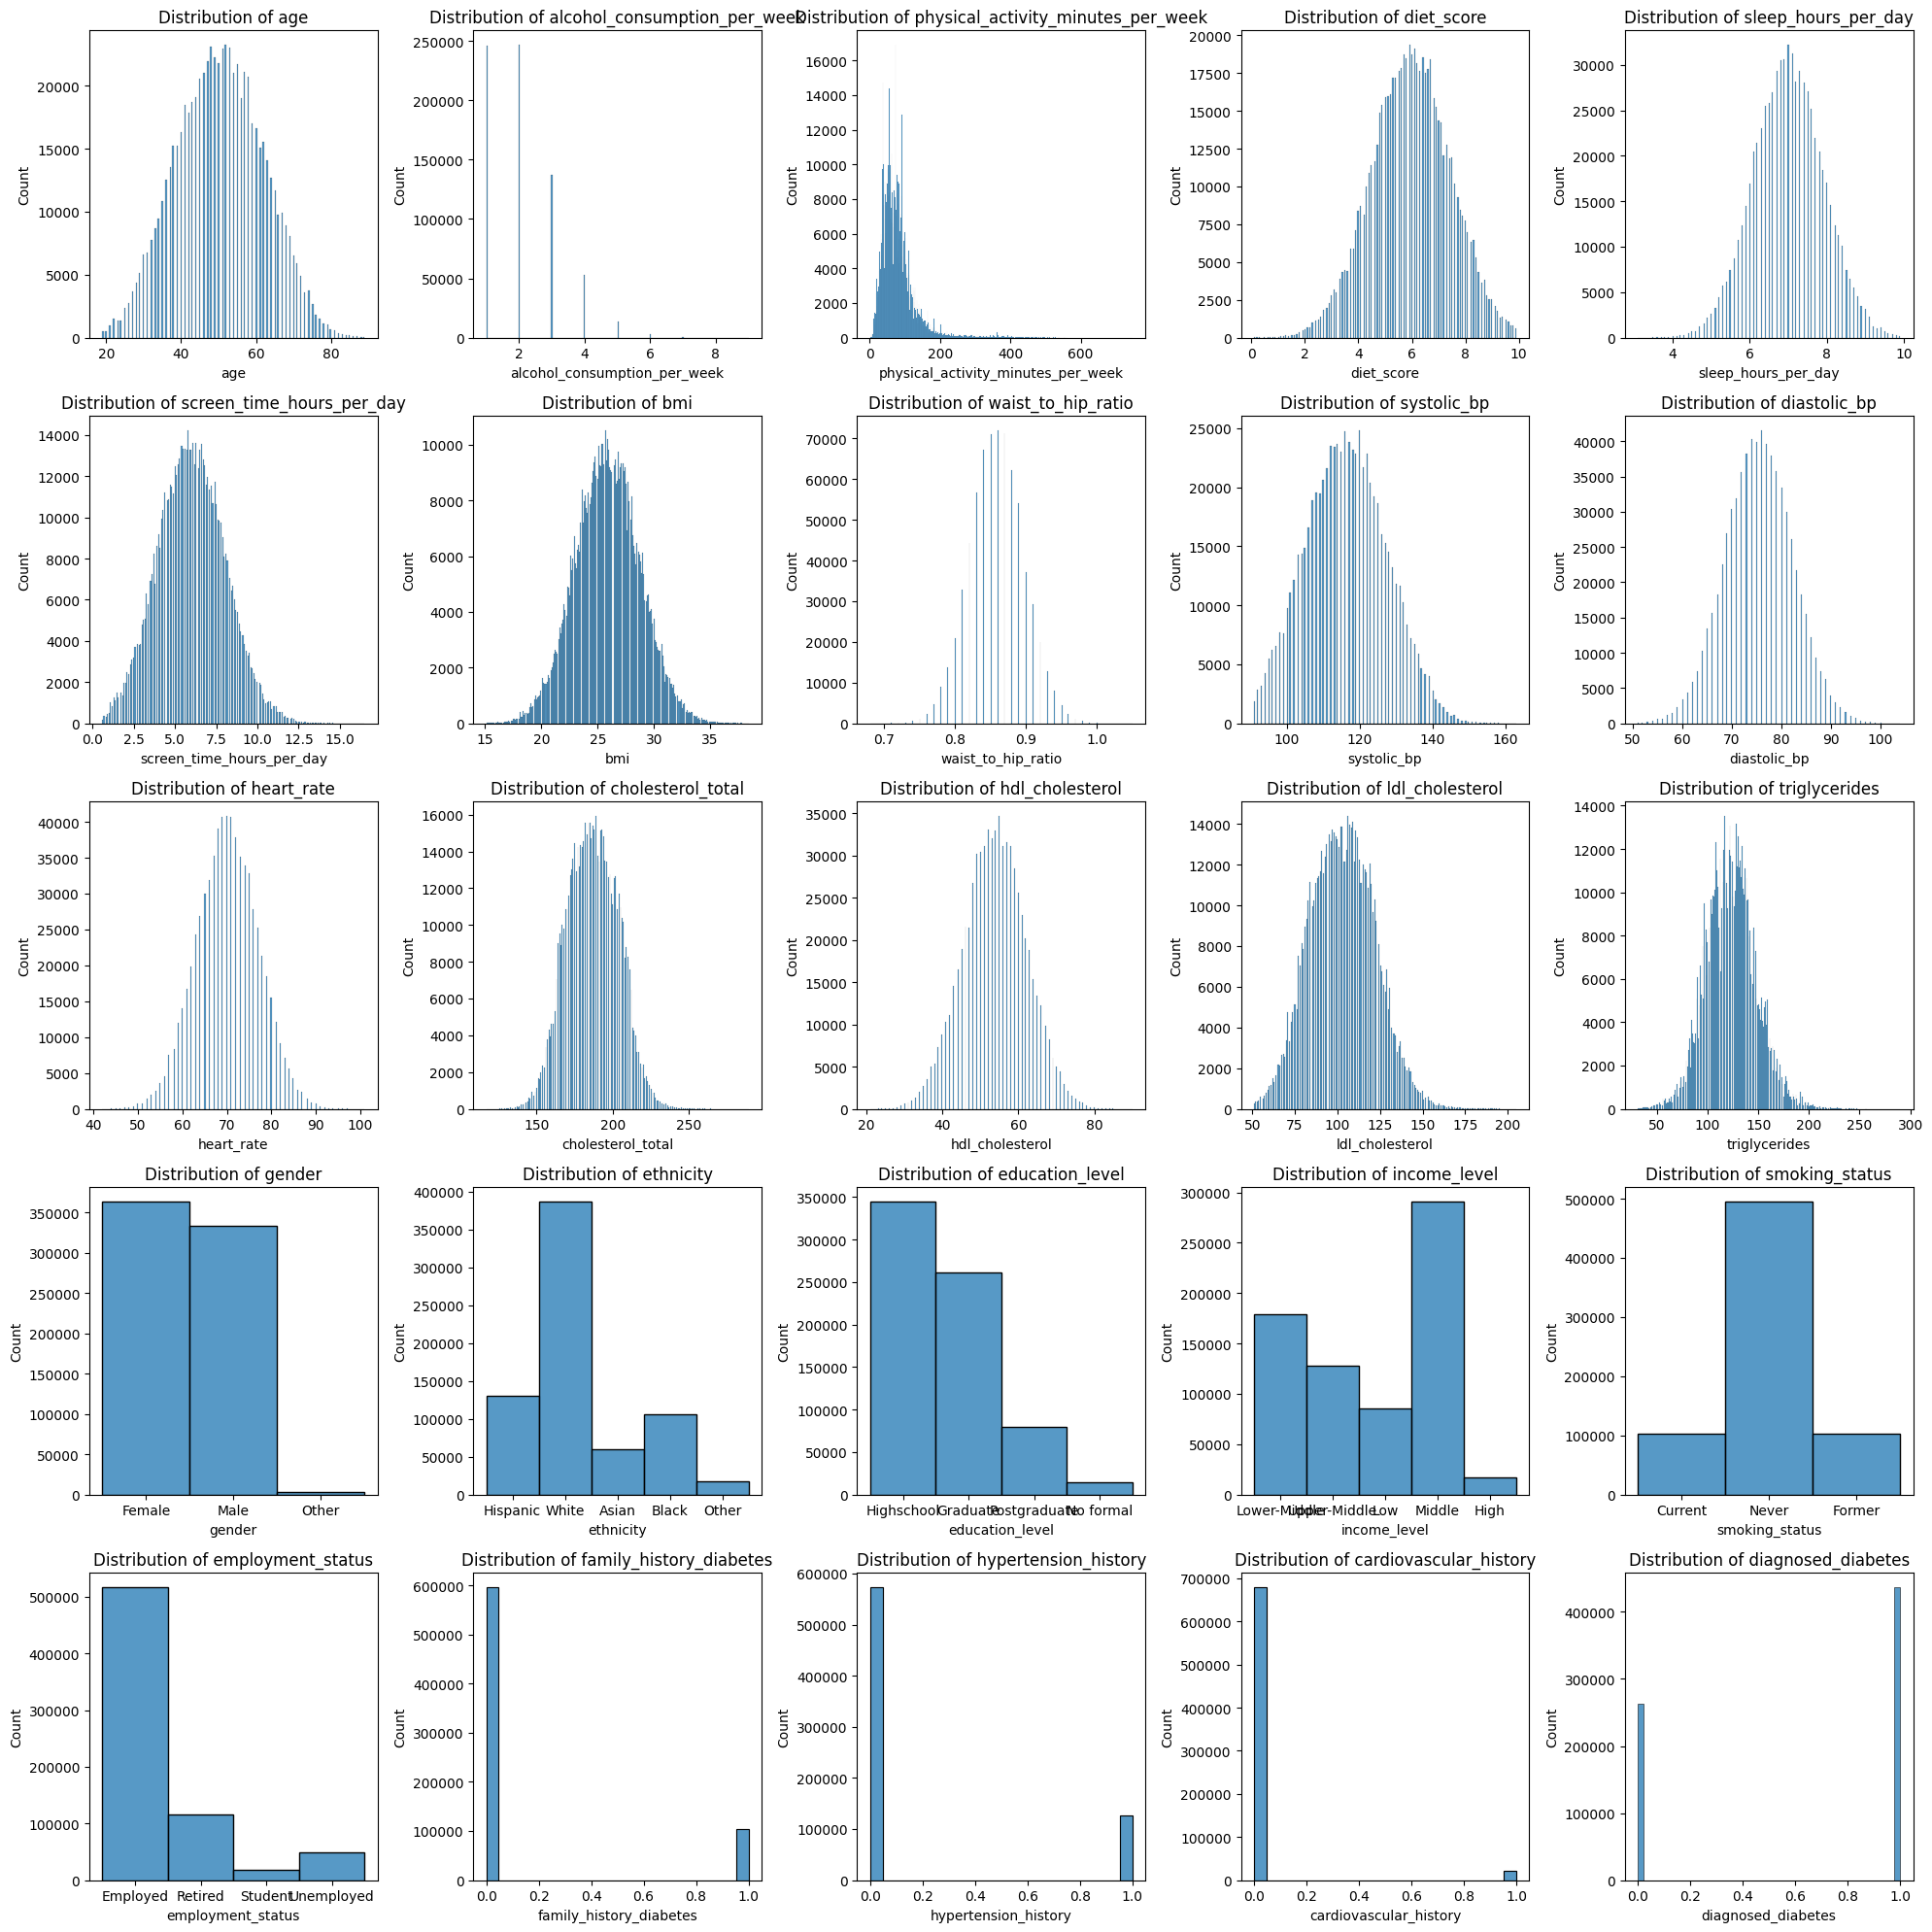

In [16]:
plot_histograms(data)

In [17]:
target = 'diagnosed_diabetes'

numerical_cols = data.drop(['diagnosed_diabetes'], axis=1).select_dtypes(include=['int32', 'float32']).columns.tolist()

categorical_cols = data.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


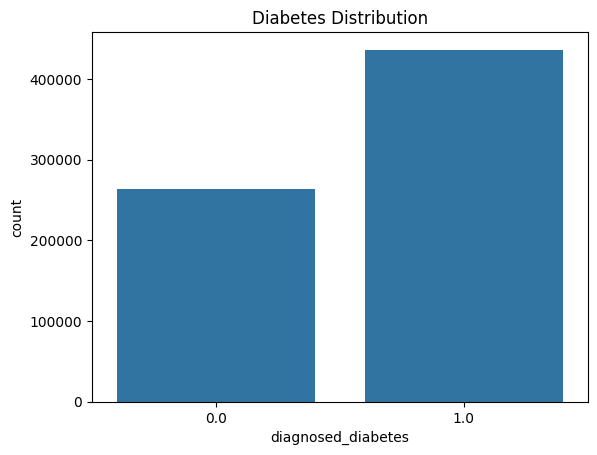

diagnosed_diabetes
1.0    0.623296
0.0    0.376704
Name: proportion, dtype: float64

In [18]:
sns.countplot(x=target, data=data)
plt.title('Diabetes Distribution')
plt.show()

data[target].value_counts(normalize=True)

Text(0.5, 1.0, 'Histogram of physical activity mpw Based on diagnosed_diabetes')

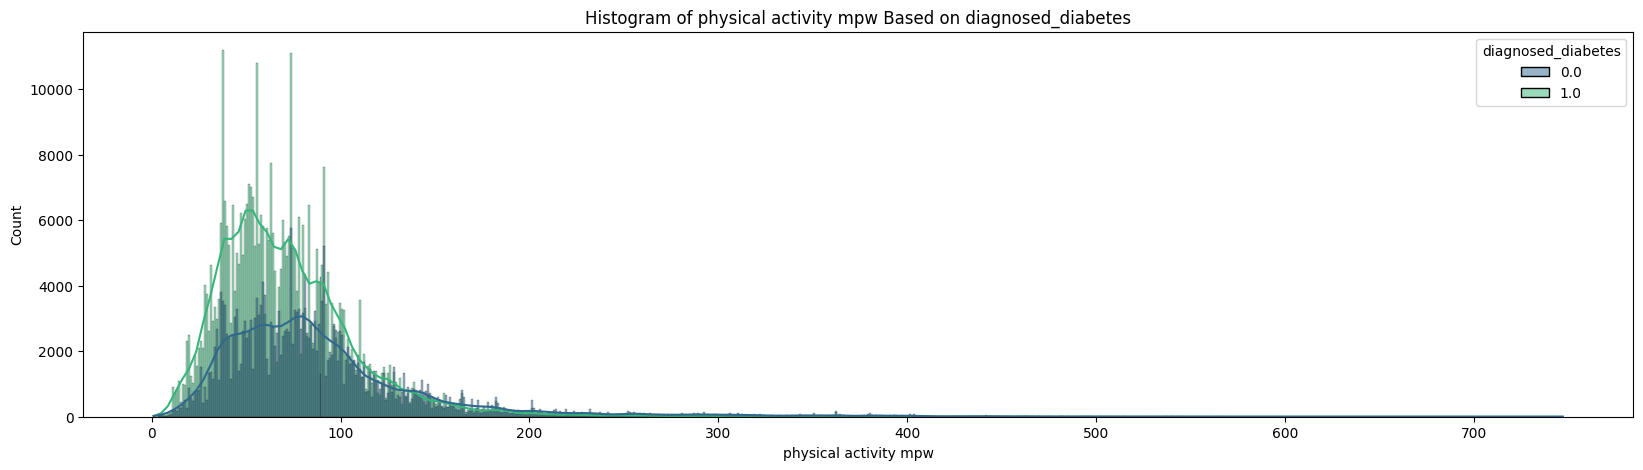

In [19]:
plt.figure(figsize=(20,5))
sns.histplot(data, x=data['physical_activity_minutes_per_week'], hue=target, palette='viridis', kde=True)
plt.xlabel('physical activity mpw')
plt.tight_layout
plt.title('Histogram of physical activity mpw Based on diagnosed_diabetes')

<Axes: xlabel='physical_activity_minutes_per_week'>

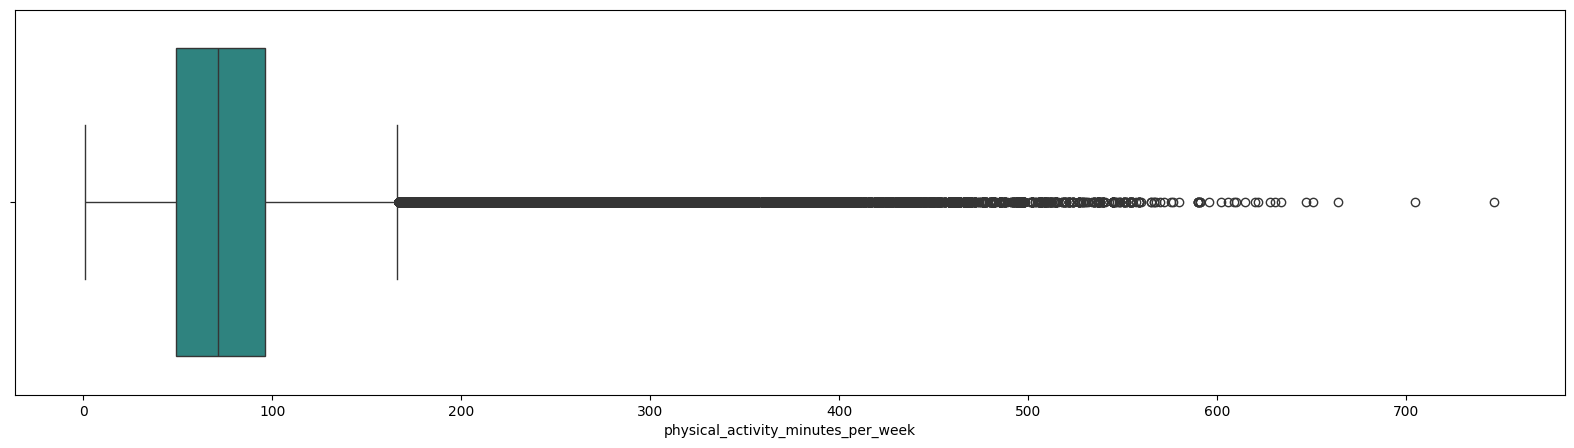

In [20]:
plt.figure(figsize=(20,5))
sns.boxplot(x=data['physical_activity_minutes_per_week'], palette='viridis')

In [21]:
def plot_categorical_percentage(df, categorical_cols, target, figsize_per_row=4, palette='mako'):

    n = len(categorical_cols)
    
    fig, axes = plt.subplots(nrows=n, ncols=1, figsize=(18, figsize_per_row * n))

    if n == 1:
        axes = [axes]

    for ax, col in zip(axes, categorical_cols):
        pct_df = (pd.crosstab(df[col], df[target], normalize='index') * 100).reset_index().melt(
            id_vars=col,
            var_name=target,
            value_name='percentage'
        )

        sns.barplot(data=pct_df, x=col, y='percentage', hue=target, palette=palette, ax=ax)
        ax.set_title(f'{col} vs {target} (%)')
        ax.set_ylabel('Percentage')
        ax.set_xlabel(col)
        ax.tick_params(axis='x', rotation=45)
        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                ax.annotate(
                    f'{height:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center',
                    va='bottom',
                    fontsize=9
                )
    plt.tight_layout()
    plt.show()


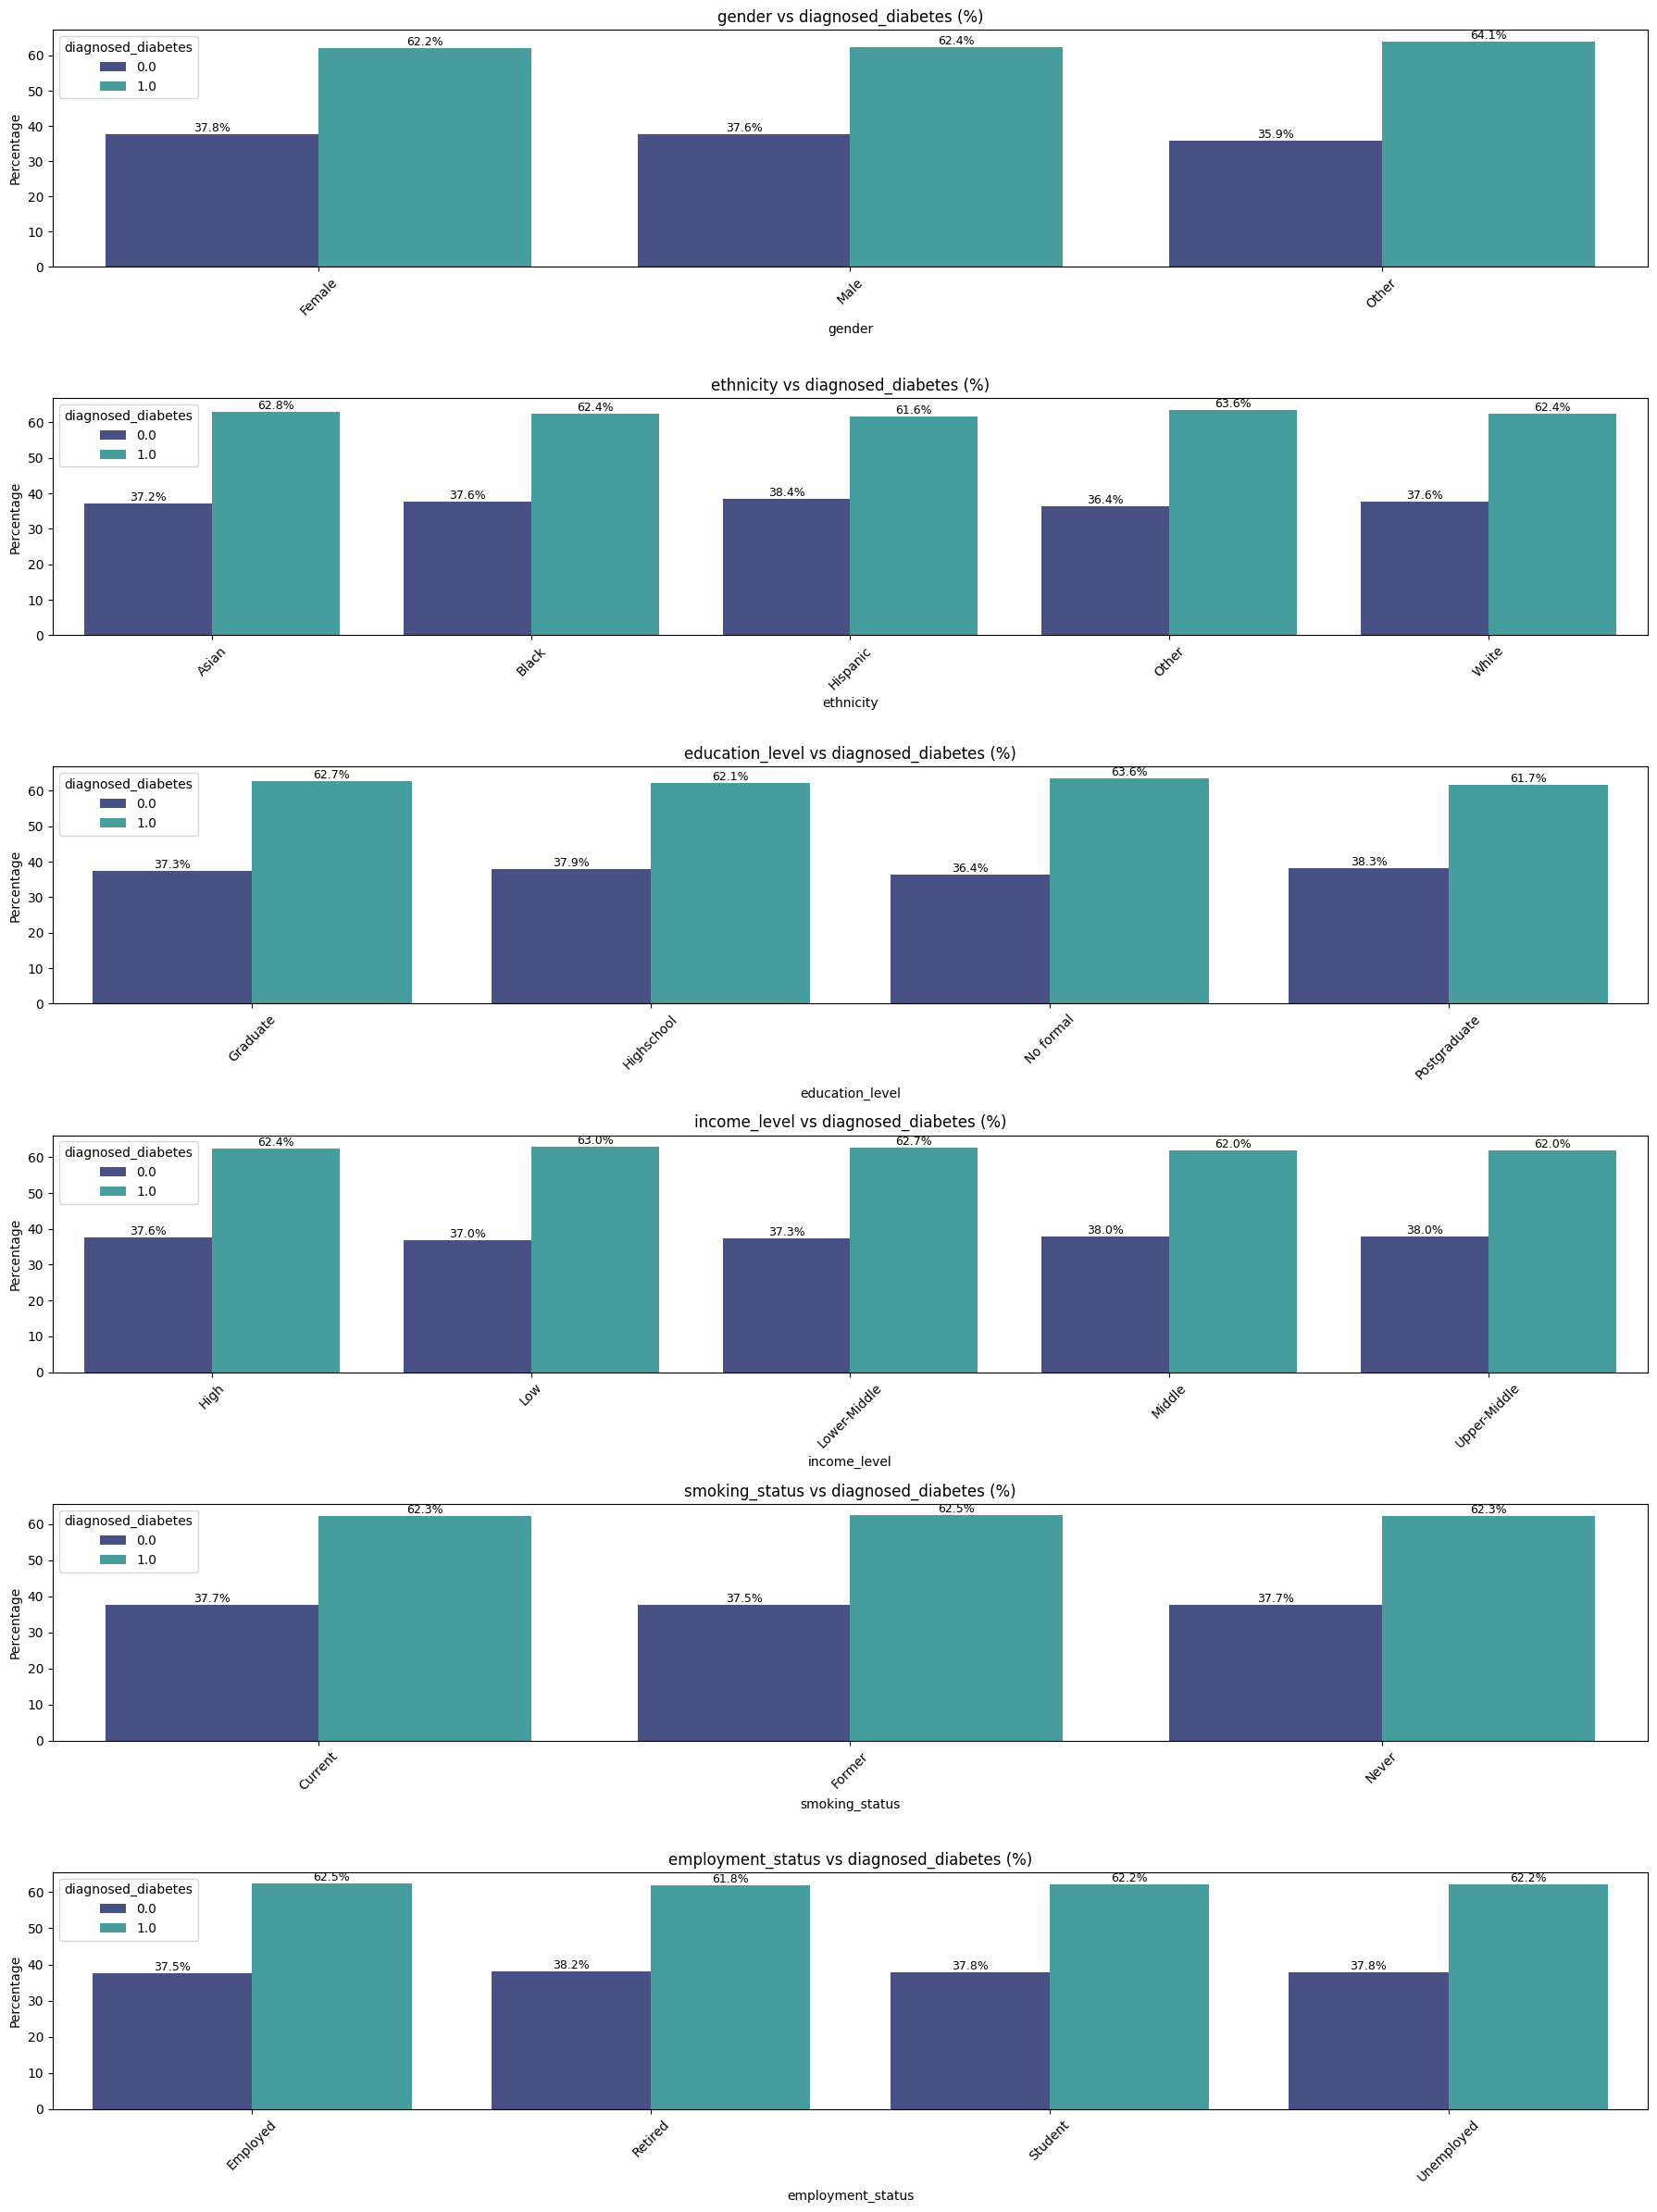

In [22]:
plot_categorical_percentage(df=data, categorical_cols=categorical_cols, target=target) 

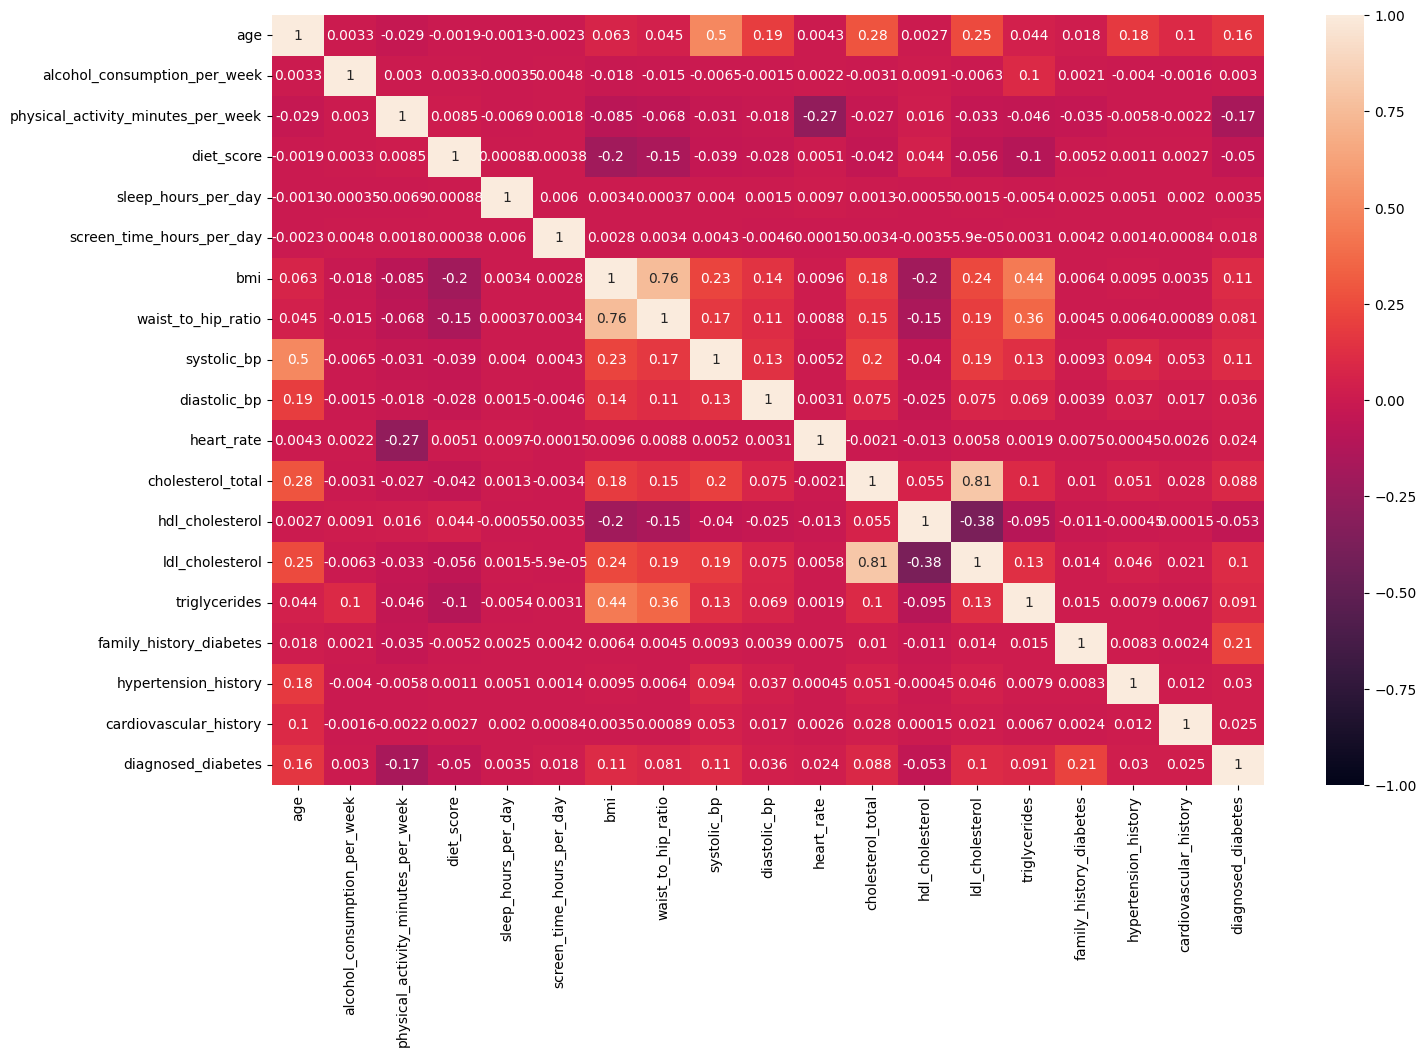

In [23]:
plt.figure(figsize=(16, 10))
sns.heatmap(data.drop(categorical_cols,axis=1).corr(), annot = True, vmin = -1, vmax = 1)
plt.show()

<div style="border-radius:10px; padding: 15px; background-color: #CDE8E5; font-size:130%; text-align:left; color: #fffff">

<h3 align="left"><font color=#4D869C>Inferences:</font></h3>
    
* Individuals with higher physical activity levels appear to have a lower risk of diabetes.
* The variable **physical_activity_minutes_per_week** contains a significant number of outliers.
* The distribution of each class is approximately normal.


<a id="preprocessing"></a>
# <p style="background-color: #4D869C; font-family:calibri; color:white; font-size:135%; font-family:Verdana; text-align:center; border-radius:15px 50px;  padding: 15px;">Step 4 | Data Preprocessing</p>
⬆️ [Tabel of Contents](#contents_tabel)

# <b><span style='color:#CDE8E5'>Step 4.1 |</span><span style='color:#4D869C'> OHE:</span></b>

In [24]:
df_cat_encoded = pd.get_dummies(
    data[categorical_cols]
)
#df_cat_encoded

In [25]:
data_ohe = pd.concat(
    [data.drop(columns=categorical_cols), df_cat_encoded],
    axis=1
)

In [26]:
data_ohe[data_ohe.select_dtypes("bool").columns] = data_ohe.select_dtypes("bool").astype("int32")

# <b><span style='color:#CDE8E5'>Step 4.2 |</span><span style='color:#4D869C'> Normalize features</span></b>

In [27]:
"""

def normal_dis(data, feature:str):
  # create new column
  data[feature] = np.sqrt(data[feature])

  # visualize
  sns.histplot(x=data[feature], label=data[feature].name, kde =True)
  plt.legend()
  plt.title(f'Distribution of {data[feature].name}')
  plt.show()
  
"""

"\n\ndef normal_dis(data, feature:str):\n  # create new column\n  data[feature] = np.sqrt(data[feature])\n\n  # visualize\n  sns.histplot(x=data[feature], label=data[feature].name, kde =True)\n  plt.legend()\n  plt.title(f'Distribution of {data[feature].name}')\n  plt.show()\n  \n"

In [28]:
"""

for i in numerical_cols:
  normal_dis(data_ohe, i)

"""

'\n\nfor i in numerical_cols:\n  normal_dis(data_ohe, i)\n\n'

In [29]:
# labels = range(1,5)
# age = pd.qcut(data["age"], q=4, labels=labels)
# data["age"] = age

# <b><span style='color:#CDE8E5'>Step 4.3 |</span><span style='color:#4D869C'> Split the Dataset:</span></b>

In [30]:
(data_ohe['diagnosed_diabetes'].value_counts() / len(data_ohe)) * 100

diagnosed_diabetes
1.0    62.329571
0.0    37.670429
Name: count, dtype: float64

In [31]:
data_ohe['diagnosed_diabetes'] = data_ohe['diagnosed_diabetes'].astype(int)

In [32]:
X = data_ohe.drop(columns=target).values
y = data_ohe[target].values

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    stratify=y, # use to split data base on Class Weight 
    train_size=0.80,
    random_state =42
)

# <b><span style='color:#CDE8E5'>Step 4.4 |</span><span style='color:#4D869C'> Treating Imbalanced data</span></b>


In [34]:
"""
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(
    sampling_strategy='auto',  # balence class
    random_state=42
)

X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)
"""

"\nfrom imblearn.over_sampling import RandomOverSampler\n\nros = RandomOverSampler(\n    sampling_strategy='auto',  # balence class\n    random_state=42\n)\n\nX_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)\n"

In [35]:
"""

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(
    X_train, y_train
)

"""

'\n\nfrom imblearn.over_sampling import SMOTE\n\nsmote = SMOTE(random_state=42)\n\nX_train_res, y_train_res = smote.fit_resample(\n    X_train, y_train\n)\n\n'

# <b><span style='color:#CDE8E5'>Step 4.5 |</span><span style='color:#4D869C'> Feature Scaling:</span></b>

In [36]:
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)

In [ ]:
import pickle

with open("StandardScaler.h5", "wb") as f:
    pickle.dump(ss, f)

<a id="modeling"></a>
# <p style="background-color: #4D869C; font-family:calibri; color:white; font-size:135%; font-family:Verdana; text-align:center; border-radius:15px 50px;  padding: 15px;">Step 5 | Model Selection</p>
⬆️ [Tabel of Contents](#contents_tabel)

<div style="border-radius:10px; padding: 15px; background-color: #CDE8E5; font-size:130%; text-align:left; color: #fffff">

<h3 align="left"><font color=#4D869C>Machine learning VS deep learning:</font></h3>
    
Machine learning models are suitable for simpler, smaller-scale tasks with structured data and require significant feature engineering. Deep learning models excel in handling large, complex datasets, often with unstructured data, and automate feature extraction, though they demand more resources and training time.
    
### Machine Learning Models

1. **Types of Models**:
   - **Supervised**: Linear regression, decision trees, SVM, random forests.
   - **Unsupervised**: K-means clustering, PCA.
   - **Reinforcement**: Q-learning.

2. **Data Requirements**:
   - Require structured data.
   - Perform well with smaller datasets.

3. **Feature Engineering**:
   - Significant manual effort required.
   - Domain knowledge often necessary.

4. **Training Time**:
   - Generally faster to train.
   - Easier to interpret and debug.

5. **Applications**:
   - Predictive modeling, classification, regression tasks.

### Deep Learning Models

1. **Types of Models**:
   - **Neural Networks**: CNNs, RNNs, LSTMs, Transformers.

2. **Data Requirements**:
   - Require large amounts of data.
   - Can handle unstructured data (images, text).

3. **Feature Engineering**:
   - Minimal manual effort required.
   - Automatically extracts features.

4. **Training Time**:
   - Often require more time and computational resources.
   - Complex and harder to interpret.

5. **Applications**:
   - Image and speech recognition, natural language processing, complex pattern recognition.



<div style="border-radius:10px; padding: 15px; background-color: #CDE8E5; font-size:130%; text-align:left; color: #fffff">

<h3 align="left"><font color=#4D869C>F1 score:</font></h3>


The F1 score is a metric used to evaluate the performance of a classification model, especially in situations where the data is imbalanced (i.e., one class is much more common than the other). It is the harmonic mean of precision and recall, providing a single score that balances both concerns.

#### Key Metrics:
1. **Precision**: This measures the accuracy of the positive predictions made by the model. It is defined as the ratio of true positive predictions to the total number of positive predictions (true positives + false positives).

   $
   \text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}}
   $

   Precision answers the question: "Of all the instances that were predicted as positive, how many were actually positive?"

2. **Recall (Sensitivity)**: This measures the ability of the model to find all the positive instances in the dataset. It is defined as the ratio of true positive predictions to the total number of actual positives (true positives + false negatives).

   $
   \text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}}
   $

   Recall answers the question: "Of all the actual positive instances, how many were correctly predicted as positive?"

#### F1 Score Calculation:
The F1 score combines precision and recall into a single metric by calculating their harmonic mean. The harmonic mean is used instead of the arithmetic mean because it punishes extreme values more, providing a more balanced metric when there is a trade-off between precision and recall.
   
   $
   \text{F1 Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}
   $

#### Why Use the F1 Score?
- **Balance**: The F1 score provides a balance between precision and recall, making it useful when you need to consider both false positives and false negatives.
- **Imbalanced Data**: It is particularly useful in imbalanced datasets where one class is significantly underrepresented. Accuracy alone might be misleading in such cases.



# <b><span style='color:#CDE8E5'>Step 5.1 |</span><span style='color:#4D869C'> Logistic Regression:</span></b>

In [37]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score

def objective(trial):

    params = {
        "C" : trial.suggest_float("C", 1e-4, 10.0, log=True),
        "solver": trial.suggest_categorical("solver", ["liblinear", "lbfgs"]),
        "max_iter":  trial.suggest_int("max_iter", 100, 1000)
    }

    model = LogisticRegression(**params, class_weight="balanced", random_state=42)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    score = cross_val_score(model, X_train, y_train, scoring='f1', cv=cv, n_jobs=-1).mean()

    return score


In [38]:
study_lg = optuna.create_study(direction='maximize')
study_lg.optimize(objective, n_trials=30)

print("Best F1:", study_lg.best_value)
print("Best Params:", study_lg.best_params)

[I 2026-01-06 13:46:09,922] A new study created in memory with name: no-name-b811db2c-1fba-46ea-81c9-3483fb271ea3
[I 2026-01-06 13:46:21,282] Trial 0 finished with value: 0.6654819292268316 and parameters: {'C': 0.0052050948393095155, 'solver': 'liblinear', 'max_iter': 745}. Best is trial 0 with value: 0.6654819292268316.
[I 2026-01-06 13:46:30,524] Trial 1 finished with value: 0.6655396316604036 and parameters: {'C': 4.099163613616578, 'solver': 'liblinear', 'max_iter': 692}. Best is trial 1 with value: 0.6655396316604036.
[I 2026-01-06 13:46:39,747] Trial 2 finished with value: 0.6655406998558145 and parameters: {'C': 0.9243215239897182, 'solver': 'liblinear', 'max_iter': 862}. Best is trial 2 with value: 0.6655406998558145.
[I 2026-01-06 13:46:49,006] Trial 3 finished with value: 0.6652864238485361 and parameters: {'C': 0.0015783013925384217, 'solver': 'liblinear', 'max_iter': 731}. Best is trial 2 with value: 0.6655406998558145.
[I 2026-01-06 13:46:51,757] Trial 4 finished with val

Best F1: 0.6664938974732102
Best Params: {'C': 0.0001020995082136328, 'solver': 'lbfgs', 'max_iter': 357}


In [39]:
lg_model = LogisticRegression(**study_lg.best_params, class_weight="balanced")
lg_model.fit(X_train,y_train)

LogisticRegression(C=0.0001020995082136328, class_weight='balanced',
                   max_iter=357)

In [40]:
y_predict_test = lg_model.predict(X_test)


# y_prob = model.predict_proba(X_test)[:,1]
# y_pred = (y_prob > 0.4).astype(int)

print(classification_report(y_test,y_predict_test))

              precision    recall  f1-score   support

           0       0.50      0.68      0.58     52739
           1       0.75      0.60      0.67     87261

    accuracy                           0.63    140000
   macro avg       0.63      0.64      0.62    140000
weighted avg       0.66      0.63      0.63    140000



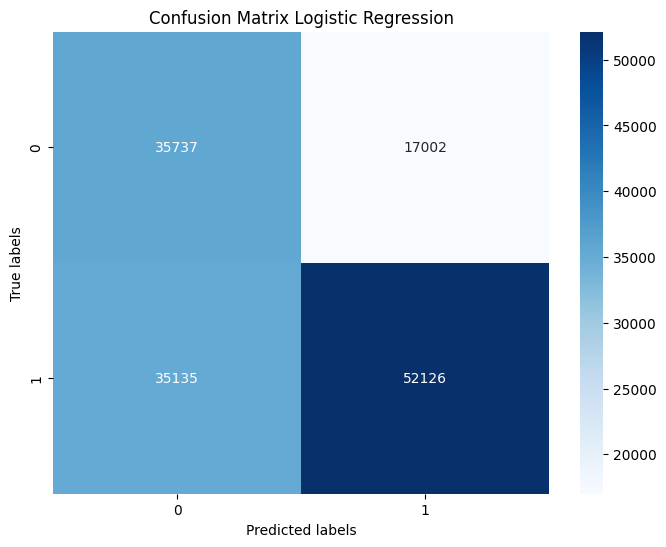

In [41]:
conf_matrix = confusion_matrix(y_test, y_predict_test)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d")
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix Logistic Regression')
plt.show()

# <b><span style='color:#CDE8E5'>Step 5.2 |</span><span style='color:#4D869C'> Decision Trees:</span></b>

In [42]:
parameters = {'criterion':['gini', 'entropy'],
              'splitter':['best', 'random'],
              'max_depth':[6, 8, 10, 15],
              'min_samples_split':[2, 4, 6, 8]}

model = DecisionTreeClassifier()
model_selection = RandomizedSearchCV(model, parameters, cv=3)
model_selection.fit(X, y)

model_selection.best_params_

{'splitter': 'best',
 'min_samples_split': 4,
 'max_depth': 8,
 'criterion': 'gini'}

In [43]:
import optuna
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

def objective(trial):

    params = {
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"]),
        "max_depth": trial.suggest_int("max_depth", 2, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 50),
        "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2", None]
        ),
        "random_state": 42
    }

    model = DecisionTreeClassifier(**params, class_weight="balanced")

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        scoring="f1",
        cv=cv,
        n_jobs=-1
    ).mean()

    return score


In [44]:
study_dt = optuna.create_study(direction="maximize")
study_dt.optimize(objective, n_trials=30)

[I 2026-01-06 13:49:58,618] A new study created in memory with name: no-name-40f09505-3983-42de-b6ea-c2347743d789
[I 2026-01-06 13:50:03,267] Trial 0 finished with value: 0.6362005800012401 and parameters: {'criterion': 'entropy', 'max_depth': 28, 'min_samples_split': 8, 'min_samples_leaf': 9, 'max_features': 'log2'}. Best is trial 0 with value: 0.6362005800012401.
[I 2026-01-06 13:50:05,518] Trial 1 finished with value: 0.6200828112889343 and parameters: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_split': 2, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.6362005800012401.
[I 2026-01-06 13:50:09,576] Trial 2 finished with value: 0.6380750050404396 and parameters: {'criterion': 'log_loss', 'max_depth': 17, 'min_samples_split': 24, 'min_samples_leaf': 8, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.6380750050404396.
[I 2026-01-06 13:50:13,905] Trial 3 finished with value: 0.6410088300760756 and parameters: {'criterion': 'log_loss', 'max_

In [45]:
print("Best F1:", study_dt.best_value)
print("Best Params:", study_dt.best_params)

Best F1: 0.6974295637535575
Best Params: {'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 43, 'min_samples_leaf': 40, 'max_features': None}


In [46]:
dtree_model = DecisionTreeClassifier(**study_dt.best_params)
dtree_model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=2, min_samples_leaf=40, min_samples_split=43)

In [47]:
y_predict_test = dtree_model.predict(X_test)

print(classification_report(y_test,y_predict_test))

              precision    recall  f1-score   support

           0       0.50      0.51      0.51     52739
           1       0.70      0.69      0.70     87261

    accuracy                           0.62    140000
   macro avg       0.60      0.60      0.60    140000
weighted avg       0.63      0.62      0.62    140000



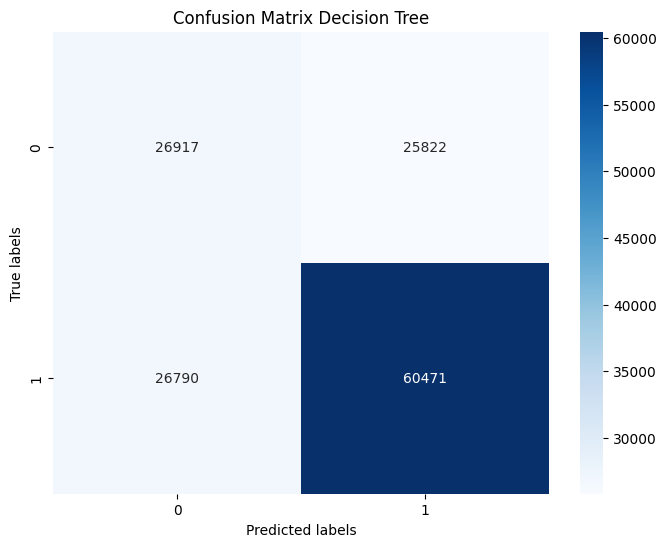

In [48]:
conf_matrix = confusion_matrix(y_test, y_predict_test)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d")
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix Decision Tree')
plt.show()

# <b><span style='color:#CDE8E5'>Step 5.3 |</span><span style='color:#4D869C'> Random Forest:</span></b>

In [49]:
parameters = {
    'n_estimators':[100, 300, 500],
    'max_depth':[6, 8, 10],
    'min_samples_split':[6, 8, 10]}

model = RandomForestClassifier()
model_selection = RandomizedSearchCV(model, parameters, cv=3)
model_selection.fit(X, y)

model_selection.best_params_

{'n_estimators': 100, 'min_samples_split': 8, 'max_depth': 10}

In [50]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 5, 40),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 50),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2"]),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
        "n_jobs": -1,
        "random_state": 42
    }

    model = RandomForestClassifier(**params)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    score = cross_val_score(model, X_train, y_train, scoring="f1", cv=cv, n_jobs=-1).mean()

    return score


In [51]:
study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(objective, n_trials=10)

[I 2026-01-06 14:53:09,677] A new study created in memory with name: no-name-d7640619-8c36-434f-9a90-2b86146a2ebb
[I 2026-01-06 14:58:14,531] Trial 0 finished with value: 0.7659527531828086 and parameters: {'n_estimators': 307, 'max_depth': 36, 'min_samples_split': 21, 'min_samples_leaf': 11, 'max_features': 'log2', 'class_weight': None}. Best is trial 0 with value: 0.7659527531828086.
[I 2026-01-06 15:01:04,291] Trial 1 finished with value: 0.7658569720950834 and parameters: {'n_estimators': 179, 'max_depth': 31, 'min_samples_split': 33, 'min_samples_leaf': 11, 'max_features': 'log2', 'class_weight': None}. Best is trial 0 with value: 0.7659527531828086.
[I 2026-01-06 15:05:41,928] Trial 2 finished with value: 0.7671435234246172 and parameters: {'n_estimators': 319, 'max_depth': 18, 'min_samples_split': 31, 'min_samples_leaf': 12, 'max_features': 'log2', 'class_weight': None}. Best is trial 2 with value: 0.7671435234246172.
[I 2026-01-06 15:13:11,882] Trial 3 finished with value: 0.76

In [52]:
print("Best F1:", study_rf.best_value)
print("Best Params:", study_rf.best_params)

Best F1: 0.7672014760232019
Best Params: {'n_estimators': 166, 'max_depth': 39, 'min_samples_split': 35, 'min_samples_leaf': 28, 'max_features': 'log2', 'class_weight': None}


In [53]:
random_forest_model = RandomForestClassifier(
    **study_rf.best_params, 
    bootstrap=True, 
    oob_score=True,
    n_jobs=-1,
    random_state=42
)
random_forest_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=39, max_features='log2', min_samples_leaf=28,
                       min_samples_split=35, n_estimators=166, n_jobs=-1,
                       oob_score=True, random_state=42)

In [54]:
y_predict_train = random_forest_model.predict(X_train)

print(classification_report(y_train,y_predict_train))

              precision    recall  f1-score   support

           0       0.75      0.39      0.52    210954
           1       0.72      0.92      0.80    349046

    accuracy                           0.72    560000
   macro avg       0.73      0.66      0.66    560000
weighted avg       0.73      0.72      0.70    560000



In [55]:
y_predict_test = random_forest_model.predict(X_test)

print(classification_report(y_test,y_predict_test))

              precision    recall  f1-score   support

           0       0.62      0.31      0.42     52739
           1       0.68      0.88      0.77     87261

    accuracy                           0.67    140000
   macro avg       0.65      0.60      0.59    140000
weighted avg       0.66      0.67      0.64    140000



In [56]:
y_predict_test = random_forest_model.predict_proba(X_test)[:,1]
y_predict_test = (y_predict_test > 0.57).astype(int)

print(classification_report(y_test,y_predict_test))

              precision    recall  f1-score   support

           0       0.55      0.53      0.54     52739
           1       0.72      0.74      0.73     87261

    accuracy                           0.66    140000
   macro avg       0.63      0.63      0.63    140000
weighted avg       0.66      0.66      0.66    140000



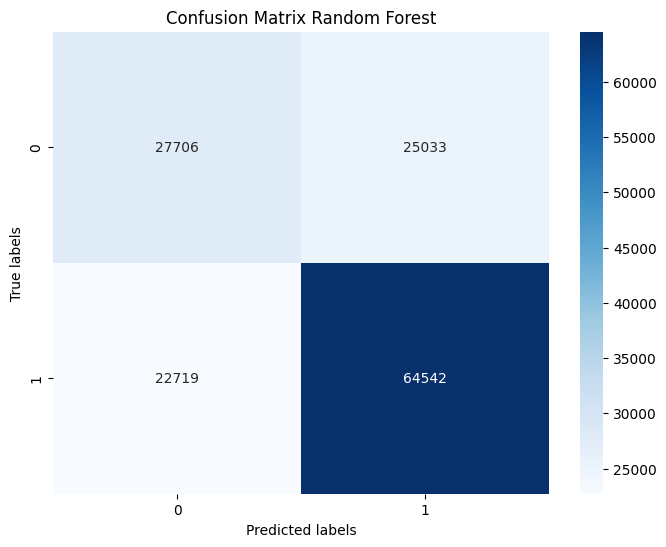

In [57]:
conf_matrix = confusion_matrix(y_test, y_predict_test)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d")
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix Random Forest')
plt.show()

# <b><span style='color:#CDE8E5'>Step 5.4 |</span><span style='color:#4D869C'> XGboost:</span></b>

In [58]:
parameters = {'n_estimators':[75, 100],
              'learning_rate':[0.1, 0.01]}
model = XGBClassifier()
model_selection = RandomizedSearchCV(model, parameters, cv=3)
model_selection.fit(X, y)

model_selection.best_params_

{'n_estimators': 100, 'learning_rate': 0.1}

In [59]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score

def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.5, 2.0)
    }

    model = XGBClassifier(**params, 
                              objective='binary:logistic', 
                              eval_metric='logloss', 
                              tree_method='hist', 
                              random_state=42)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    score = cross_val_score(model, X_train, y_train, scoring='f1', cv=cv, n_jobs=-1).mean()

    return score


In [60]:
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective, n_trials=30)

print("Best F1:", study_xgb.best_value)
print("Best Params:", study_xgb.best_params)

[I 2026-01-06 15:45:20,708] A new study created in memory with name: no-name-e4057497-b6fd-44c0-ad1b-eb9a9a71b852
[I 2026-01-06 15:47:03,415] Trial 0 finished with value: 0.7729763327044884 and parameters: {'n_estimators': 506, 'max_depth': 9, 'learning_rate': 0.1617136243774312, 'subsample': 0.6925460441424063, 'colsample_bytree': 0.652910136289942, 'gamma': 0.1266667719588055, 'min_child_weight': 5, 'reg_alpha': 0.00015940250765669715, 'reg_lambda': 0.0011607378918271354, 'scale_pos_weight': 1.7982279506310443}. Best is trial 0 with value: 0.7729763327044884.
[I 2026-01-06 15:48:54,691] Trial 1 finished with value: 0.7752807396049518 and parameters: {'n_estimators': 430, 'max_depth': 10, 'learning_rate': 0.01499966358035187, 'subsample': 0.7034551517435037, 'colsample_bytree': 0.8866990923064538, 'gamma': 4.213083289243086, 'min_child_weight': 6, 'reg_alpha': 0.6885531231337175, 'reg_lambda': 2.427218874891181, 'scale_pos_weight': 1.1461434726455821}. Best is trial 1 with value: 0.77

Best F1: 0.7795637332411015
Best Params: {'n_estimators': 521, 'max_depth': 7, 'learning_rate': 0.04229967756623378, 'subsample': 0.8587675323324315, 'colsample_bytree': 0.7825030216179316, 'gamma': 3.8750981212907747, 'min_child_weight': 9, 'reg_alpha': 0.0014849099589997585, 'reg_lambda': 0.0014391519297313911, 'scale_pos_weight': 1.519718846555516}


In [61]:
xgb_model = XGBClassifier(**study_xgb.best_params)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7825030216179316, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=3.8750981212907747, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.04229967756623378,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=9, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=521, n_jobs=None,
              num_parallel_tree=None, ...)

In [62]:
y_predict_train = xgb_model.predict(X_train)

print(classification_report(y_train,y_predict_train))

              precision    recall  f1-score   support

           0       0.75      0.23      0.35    210954
           1       0.67      0.95      0.79    349046

    accuracy                           0.68    560000
   macro avg       0.71      0.59      0.57    560000
weighted avg       0.70      0.68      0.62    560000



In [63]:
y_predict_test = xgb_model.predict(X_test)

print(classification_report(y_test,y_predict_test))

              precision    recall  f1-score   support

           0       0.70      0.21      0.32     52739
           1       0.66      0.94      0.78     87261

    accuracy                           0.67    140000
   macro avg       0.68      0.58      0.55    140000
weighted avg       0.68      0.67      0.61    140000



In [108]:
y_predict_test = xgb_model.predict_proba(X_test)[:,1]
y_predict_test = (y_predict_test > 0.6).astype(int)

print(classification_report(y_test,y_predict_test))

              precision    recall  f1-score   support

           0       0.62      0.41      0.50     52739
           1       0.70      0.84      0.77     87261

    accuracy                           0.68    140000
   macro avg       0.66      0.63      0.63    140000
weighted avg       0.67      0.68      0.67    140000



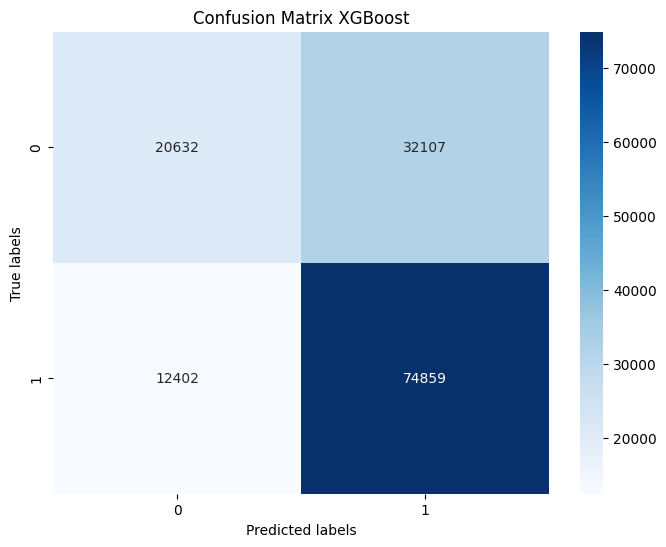

In [65]:
conf_matrix = confusion_matrix(y_test, y_predict_test)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d")
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix XGBoost')
plt.show()

# <b><span style='color:#CDE8E5'>Step 5.5.1 |</span><span style='color:#4D869C'>Ensemble Model: Voting</span></b>

In [66]:
from sklearn.ensemble import VotingClassifier


rf_ens_model = RandomForestClassifier(**study_rf.best_params)
xgb_ens_model = XGBClassifier(**study_xgb.best_params)
lr_ens_model = LogisticRegression(**study_lg.best_params)

# Voting Ensemble
ensemble = VotingClassifier(
    estimators=[('rf', rf_ens_model), ('xgb', xgb_ens_model), ('lr', lr_ens_model)],
    voting='soft'  # hard
        )

ensemble.fit(X_train, y_train)

VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(max_depth=39,
                                                     max_features='log2',
                                                     min_samples_leaf=28,
                                                     min_samples_split=35,
                                                     n_estimators=166)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.7825030216179316,
                                            device=None,
                                            early_stopping_rounds=None,
                                            enable_categor...
                                            learning_rate=0.04229967756623378,
                                            max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=7,
                                            max_leaves=None, min_child_weight=9,
                                            missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=521, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('lr',
                              LogisticRegression(C=0.0001020995082136328,
                                                 max_iter=357))],
                 voting='soft')

In [67]:
y_predict_train = ensemble.predict(X_train)

print(classification_report(y_train,y_predict_train))

              precision    recall  f1-score   support

           0       0.72      0.29      0.41    210954
           1       0.68      0.93      0.79    349046

    accuracy                           0.69    560000
   macro avg       0.70      0.61      0.60    560000
weighted avg       0.70      0.69      0.65    560000



In [68]:
y_predict_test = ensemble.predict(X_test)

print(classification_report(y_test,y_predict_test))

              precision    recall  f1-score   support

           0       0.65      0.26      0.37     52739
           1       0.67      0.92      0.78     87261

    accuracy                           0.67    140000
   macro avg       0.66      0.59      0.57    140000
weighted avg       0.66      0.67      0.62    140000



In [113]:
y_predict_test = ensemble.predict_proba(X_test)[:,1]
y_predict_test = (y_predict_test > 0.54).astype(int)

print(classification_report(y_test,y_predict_test))

              precision    recall  f1-score   support

           0       0.62      0.36      0.46     52739
           1       0.69      0.86      0.77     87261

    accuracy                           0.68    140000
   macro avg       0.66      0.61      0.61    140000
weighted avg       0.66      0.68      0.65    140000



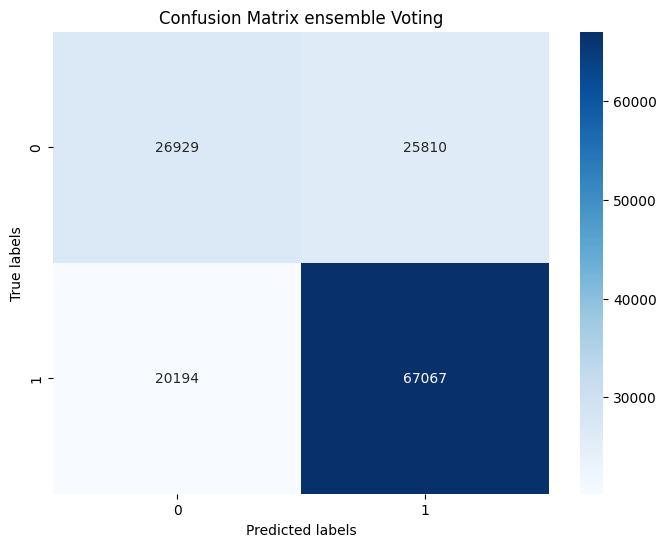

In [70]:
conf_matrix = confusion_matrix(y_test, y_predict_test)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d")
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix ensemble Voting')
plt.show()

# <b><span style='color:#CDE8E5'>Step 5.5.2 |</span><span style='color:#4D869C'> Ensemble Model: Stacking</span></b>

In [71]:
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC

base_models = [
    ('lr', LogisticRegression(**study_lg.best_params)),
    ('rf', RandomForestClassifier(**study_rf.best_params)),
    ('xgb', XGBClassifier(**study_xgb.best_params))
]

stacking = StackingClassifier(
    estimators=base_models, 
    final_estimator=LogisticRegression(), 
    cv=5, 
    n_jobs=-1)

stacking.fit(X_train, y_train)


StackingClassifier(cv=5,
                   estimators=[('lr',
                                LogisticRegression(C=0.0001020995082136328,
                                                   max_iter=357)),
                               ('rf',
                                RandomForestClassifier(max_depth=39,
                                                       max_features='log2',
                                                       min_samples_leaf=28,
                                                       min_samples_split=35,
                                                       n_estimators=166)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=0...
                                              interaction_constraints=None,
                                              learning_rate=0.04229967756623378,
                                              max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=7,
                                              max_leaves=None,
                                              min_child_weight=9, missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=521, n_jobs=None,
                                              num_parallel_tree=None, ...))],
                   final_estimator=LogisticRegression(), n_jobs=-1)

In [72]:
y_predict_train = stacking.predict(X_train)

print(classification_report(y_train,y_predict_train))

              precision    recall  f1-score   support

           0       0.66      0.44      0.53    210954
           1       0.72      0.86      0.78    349046

    accuracy                           0.70    560000
   macro avg       0.69      0.65      0.65    560000
weighted avg       0.70      0.70      0.69    560000



In [73]:
y_predict_test = stacking.predict(X_test)

print(classification_report(y_test,y_predict_test))

              precision    recall  f1-score   support

           0       0.62      0.41      0.49     52739
           1       0.70      0.85      0.77     87261

    accuracy                           0.68    140000
   macro avg       0.66      0.63      0.63    140000
weighted avg       0.67      0.68      0.67    140000



In [114]:
y_predict_test = stacking.predict_proba(X_test)[:,1]
y_predict_test = (y_predict_test > 0.58).astype(int)

print(classification_report(y_test,y_predict_test))

              precision    recall  f1-score   support

           0       0.58      0.56      0.57     52739
           1       0.74      0.75      0.74     87261

    accuracy                           0.68    140000
   macro avg       0.66      0.65      0.66    140000
weighted avg       0.68      0.68      0.68    140000



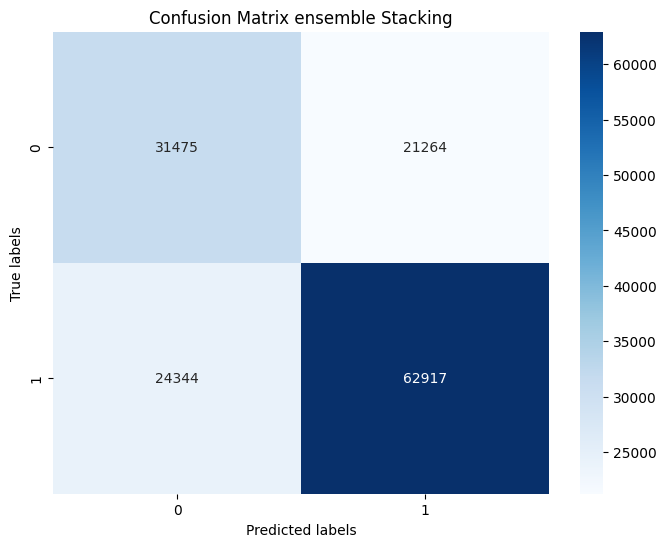

In [75]:
conf_matrix = confusion_matrix(y_test, y_predict_test)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d")
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix ensemble Stacking')
plt.show()

# <b><span style='color:#CDE8E5'>Step 5.6 |</span><span style='color:#4D869C'> Fully Connected Neural Networks:</span></b>

In [76]:
import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

2026-01-06 16:34:28.931119: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767717269.566311      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767717269.719197      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767717271.143140      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767717271.143167      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767717271.143170      55 computation_placer.cc:177] computation placer alr

In [77]:
#y = to_categorical(y , num_classes=2)
#X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.80, random_state =42)

In [86]:
# Define the model
model = tf.keras.Sequential(
    [
        tf.keras.Input(shape=X_train.shape[1:]),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ]
)

In [87]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [88]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 32)             │         1,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,177 (86.63 KB)

 Trainable params: 22,177 (86.63 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
#plot_model(model, show_layer_activations=True, show_shapes=True)

In [89]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import TensorBoard

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5),
    ModelCheckpoint('best_model.h5', save_best_only=True),
    TensorBoard(log_dir='./logs')
]

In [90]:
model.fit(
    X_train,
    y_train, 
    epochs=100, 
    validation_data=(X_test, y_test), 
    callbacks=callbacks,
    batch_size=128
)

Epoch 1/100
4362/4375 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6538 - loss: 0.6144

4375/4375 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.6538 - loss: 0.6143 - val_accuracy: 0.6625 - val_loss: 0.6063 - learning_rate: 0.0010
Epoch 2/100
4368/4375 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6619 - loss: 0.6054

4375/4375 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.6619 - loss: 0.6054 - val_accuracy: 0.6637 - val_loss: 0.6047 - learning_rate: 0.0010
Epoch 3/100
4359/4375 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6616 - loss: 0.6057

4375/4375 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.6616 - loss: 0.6056 - val_accuracy: 0.6636 - val_loss: 0.6038 - learning_rate: 0.0010
Epoch 4/100
4367/4375 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6630 - loss: 0.6043

4375/4375 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.6630 - loss: 0.6043 - val_accuracy: 0.6637 - val_loss: 0.6031 - learning_rate: 0.0010
Epoch 5/100
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.6640 - loss: 0.6032 - val_accuracy: 0.6630 - val_loss: 0.6036 - learning_rate: 0.0010
Epoch 6/100
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.6647 - loss: 0.6031 - val_accuracy: 0.6623 - val_loss: 0.6047 - learning_rate: 0.0010
Epoch 7/100
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.6641 - loss: 0.6032 - val_accuracy: 0.6636 - val_loss: 0.6044 - learning_rate: 0.0010
Epoch 8/100
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.6635 - loss: 0.6029 - val_accuracy: 0.6635 - val_loss: 0.6052 - learning_rate: 0.0010
Epoch 9/100
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.6643 - loss: 0.6026 - val_accuracy: 0.6638 - val_loss: 0.6034 - learning_rate: 0.0010
Epoch 10/100
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.6654 

In [85]:
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Loss: {loss}, Accuracy: {accuracy}")

4375/4375 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - categorical_accuracy: 0.6137 - loss: 0.0000e+00
Loss: 0.0, Accuracy: 0.6111999750137329


In [100]:
# Predict the labels for the test set
y_prob = model.predict(X_test)
y_pred = (y_prob > 0.59).astype(int)

# Generate classification report
report = classification_report(y_test, y_pred)
print(report)

4375/4375 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
              precision    recall  f1-score   support

           0       0.53      0.58      0.55     52739
           1       0.73      0.69      0.71     87261

    accuracy                           0.65    140000
   macro avg       0.63      0.63      0.63    140000
weighted avg       0.65      0.65      0.65    140000



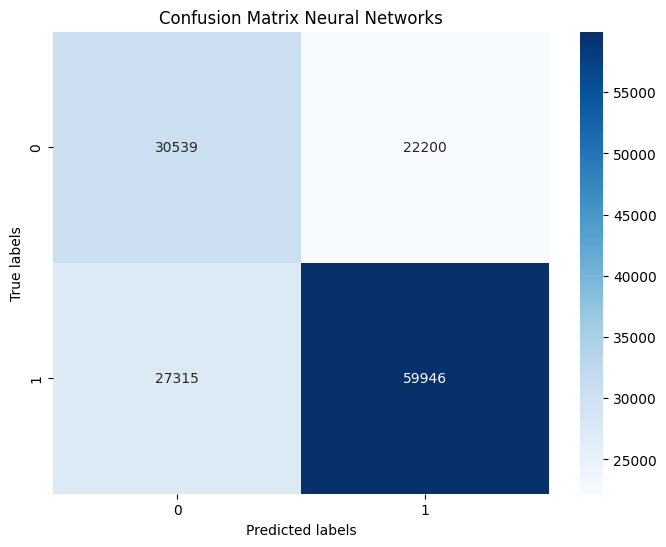

In [103]:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d")
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix Neural Networks')
plt.show()

<a id="conclusions"></a>
# <p style="background-color: #4D869C; font-family:calibri; color:white; font-size:135%; font-family:Verdana; text-align:center; border-radius:15px 50px;  padding: 15px;">Step 6 | Comparison models & Submit</p>
⬆️ [Tabel of Contents](#contents_tabel)

<div style="border-radius:10px; padding: 15px; background-color: #CDE8E5; font-size:130%; text-align:left; color: #fffff">

<h3 align="left"><font color=#4D869C>Comparison models:</font></h3>
    

In this project, we explored various machine learning models to evaluate their performance on our dataset. The models investigated included Logistic regression, decision trees, random forests, ensemble model(voting/ stacking), and gradient boosting machines(XG-Boost). Additionally, we delved into deep learning techniques, specifically deep neural networks.

Our evaluation metric of choice was the F1 score, which balances precision and recall to provide a comprehensive measure of model performance, particularly in scenarios with imbalanced datasets.



| Model                    | F1-score  |
| :---                     | :----:    |
| Logistic Regression      | 0.67      |
| Decision Trees           | 0.70      |
| Random Forest            | 0.73      |
| XGboost                  | 0.77      |
| ensemble voting          | 0.77      |
| ensemble stacking        | 0.74      |
| Deep Neural Networks     | 0.71      |



# <b><span style='color:#CDE8E5'>Step 6.1 |</span><span style='color:#4D869C'> Preprocessing test dataset:</span></b>

In [105]:
data_test = pd.read_csv("/kaggle/input/playground-series-s5e12/test.csv")
test_ids = data_test["id"]
data_test.drop(["id"], axis=1, inplace=True)

In [115]:
df_cat_encoded = pd.get_dummies(
    data_test[categorical_cols]
)
data_ohe = pd.concat(
    [data_test.drop(columns=categorical_cols), df_cat_encoded],
    axis=1
)
data_ohe[data_ohe.select_dtypes("bool").columns] = data_ohe.select_dtypes("bool").astype("int32")

In [116]:
X_sub = ss.transform(data_ohe)

# <b><span style='color:#CDE8E5'>Step 6.2 |</span><span style='color:#4D869C'> Submit:</span></b>

In [117]:
y_predict_test = xgb_model.predict_proba(X_sub)[:,1]
y_pred_submission = (y_predict_test > 0.6).astype(int)

In [118]:
submission = pd.DataFrame({
    "id": test_ids,
    "diagnosed_diabetes": y_pred_submission
})
submission.head()

,id,diagnosed_diabetes
0,700000,0
1,700001,1
2,700002,1
3,700003,0
4,700004,1


In [119]:
submission.to_csv("submission.csv", index=False)

In [ ]:
# end